# Ellipse Packing Contest — Search Lab

Complete end-to-end baseline for packing 67 identical ellipses for `(2,1)`, `(3,1)`, and `(3,2)`. The solver keeps geometry, search, validation, and serialization separate so we can improve each component strategically.

In [1]:
import math, random, time, re, os
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from scipy.optimize import minimize_scalar
    SCIPY=True
except Exception:
    SCIPY=False
SEED=42; random.seed(SEED); np.random.seed(SEED)
N=67
SHAPES={"2:1":(2.0,1.0),"3:1":(3.0,1.0),"3:2":(3.0,2.0)}
EPS=1e-9
print(N, SHAPES, "SciPy:", SCIPY)

67 {'2:1': (2.0, 1.0), '3:1': (3.0, 1.0), '3:2': (3.0, 2.0)} SciPy: True


## 1. State, density and geometry

An ellipse is represented by semi-axes `(a,b)`, center `(x,y)`, and rotation `theta` in radians.

In [2]:
@dataclass
class PackingState:
    W: float; H: float; x: np.ndarray; y: np.ndarray; theta: np.ndarray
    def copy(self): return PackingState(float(self.W),float(self.H),self.x.copy(),self.y.copy(),self.theta.copy())
    @property
    def area(self): return self.W*self.H
@dataclass
class Geometry:
    a: float; b: float; n:int=N
    @property
    def ellipse_area(self): return math.pi*self.a*self.b
    @property
    def total_area(self): return self.n*self.ellipse_area
def density(s,g): return g.total_area/s.area
def half_extents(a,b,t):
    c=np.cos(t); q=np.sin(t); return np.sqrt(a*a*c*c+b*b*q*q), np.sqrt(a*a*q*q+b*b*c*c)
def all_aabbs(s,g):
    rx,ry=half_extents(g.a,g.b,s.theta); return s.x-rx,s.x+rx,s.y-ry,s.y+ry
def boundary_violation(s,g):
    rx,ry=half_extents(g.a,g.b,s.theta)
    return float(np.sum(np.maximum(0,rx-s.x)+np.maximum(0,s.x+rx-s.W)+np.maximum(0,ry-s.y)+np.maximum(0,s.y+ry-s.H)))
def point_q(px,py,cx,cy,a,b,t):
    dx=px-cx; dy=py-cy; c=math.cos(t); q=math.sin(t); u=c*dx+q*dy; v=-q*dx+c*dy
    return (u/a)**2+(v/b)**2
def inside(px,py,cx,cy,a,b,t,tol=1e-10): return point_q(px,py,cx,cy,a,b,t)<=1+tol
def candidate_pairs(s,g):
    xmin,xmax,ymin,ymax=all_aabbs(s,g); out=[]
    for i in range(g.n):
        for j in range(i+1,g.n):
            if not(xmax[i]<=xmin[j] or xmax[j]<=xmin[i] or ymax[i]<=ymin[j] or ymax[j]<=ymin[i]): out.append((i,j))
    return out
def bpoint(cx,cy,a,b,t,z):
    c=math.cos(t); q=math.sin(t); return cx+c*a*math.cos(z)-q*b*math.sin(z), cy+q*a*math.cos(z)+c*b*math.sin(z)
def min_q_boundary(e1,e2,g,samples=40):
    x1,y1,t1=e1; x2,y2,t2=e2
    def f(z):
        px,py=bpoint(x1,y1,g.a,g.b,t1,z); return point_q(px,py,x2,y2,g.a,g.b,t2)
    ts=np.linspace(0,2*math.pi,samples,endpoint=False); vals=np.array([f(z) for z in ts]); best=float(vals.min())
    if SCIPY:
        step=2*math.pi/samples
        for k in np.argsort(vals)[:6]:
            r=minimize_scalar(lambda z:f(z%(2*math.pi)),bounds=(ts[k]-step,ts[k]+step),method='bounded')
            best=min(best,float(r.fun))
    return best
def ellipses_overlap(i,j,s,g,tol=1e-9):
    xi,yi,ti=float(s.x[i]),float(s.y[i]),float(s.theta[i]); xj,yj,tj=float(s.x[j]),float(s.y[j]),float(s.theta[j])
    rxi,ryi=half_extents(g.a,g.b,ti); rxj,ryj=half_extents(g.a,g.b,tj)
    if xi+rxi<xj-rxj-tol or xj+rxj<xi-rxi-tol or yi+ryi<yj-ryj-tol or yj+ryj<yi-ryi-tol: return False
    if inside(xi,yi,xj,yj,g.a,g.b,tj,tol) or inside(xj,yj,xi,yi,g.a,g.b,ti,tol): return True
    return min_q_boundary((xi,yi,ti),(xj,yj,tj),g)<=1+tol or min_q_boundary((xj,yj,tj),(xi,yi,ti),g)<=1+tol
def collision_count(s,g): return sum(ellipses_overlap(i,j,s,g) for i,j in candidate_pairs(s,g))
def feasible(s,g): return boundary_violation(s,g)<=1e-8 and collision_count(s,g)==0

## 2. Structured initializers

In [3]:
def grid_initializer(g,nx=9,ny=8,angle=0):
    if nx*ny<g.n: raise ValueError('not enough positions')
    W=nx*2*g.a+2; H=ny*2*g.b+2; xs=np.linspace(g.a,W-g.a,nx); ys=np.linspace(g.b,H-g.b,ny)
    p=np.array([(x,y) for y in ys for x in xs])[:g.n]
    return PackingState(W,H,p[:,0],p[:,1],np.full(g.n,angle))
def staggered_initializer(g,nx=9,ny=8,angle=0,gap=.08):
    sx,sy=2*g.a+gap,2*g.b+gap; pts=[]
    for r in range(ny):
        off=.5*sx if r%2 else 0
        for col in range(nx): pts.append((g.a+col*sx+off,g.b+r*sy))
    p=np.array(pts)[:g.n]; W=p[:,0].max()+g.a; H=p[:,1].max()+g.b
    return PackingState(W,H,p[:,0],p[:,1],np.full(g.n,angle))
def rotated_lattice_initializer(g,nx=9,ny=8,angle=0,gap=.08):
    rx,ry=half_extents(g.a,g.b,angle); sx,sy=2*rx+gap,2*ry+gap
    p=np.array([(rx+c*sx,ry+r*sy) for r in range(ny) for c in range(nx)])[:g.n]
    return PackingState(p[:,0].max()+rx,p[:,1].max()+ry,p[:,0],p[:,1],np.full(g.n,angle))
def portfolio(g):
    out=[]
    for a in [0,math.pi/2]: out.append(('grid',grid_initializer(g,angle=a)))
    for a in [0,math.pi/6,math.pi/4,math.pi/3]: out.append(('staggered',staggered_initializer(g,angle=a)))
    for a in np.linspace(0,math.pi/2,7,endpoint=False): out.append(('rotated',rotated_lattice_initializer(g,angle=float(a))))
    return out

## 3. Fast search objective, repair, simulated annealing

In [4]:
def aabb_overlap_area(i,j,s,g):
    xmin,xmax,ymin,ymax=all_aabbs(s,g); return max(0,min(xmax[i],xmax[j])-max(xmin[i],xmin[j]))*max(0,min(ymax[i],ymax[j])-max(ymin[i],ymin[j]))
def fast_penalty(s,g): return sum(aabb_overlap_area(i,j,s,g) for i,j in candidate_pairs(s,g))
def energy(s,g,cw=2e4,bw=2e5): return s.area+cw*fast_penalty(s,g)+bw*boundary_violation(s,g)
def repair(s,g,max_iter=900):
    s=s.copy()
    for it in range(max_iter):
        rx,ry=half_extents(g.a,g.b,s.theta); viol=np.maximum(0,rx-s.x)+np.maximum(0,s.x+rx-s.W)+np.maximum(0,ry-s.y)+np.maximum(0,s.y+ry-s.H)
        pairs=candidate_pairs(s,g)
        if viol.max()<=1e-10 and not pairs: return s
        if viol.max()>0:
            i=int(np.argmax(viol)); s.x[i]=np.clip(s.x[i],rx[i],s.W-rx[i]); s.y[i]=np.clip(s.y[i],ry[i],s.H-ry[i]); continue
        counts=np.zeros(g.n,int)
        for i,j in pairs: counts[i]+=1; counts[j]+=1
        i=int(np.argmax(counts)); f=np.zeros(2)
        for p,q in pairs:
            if p!=i and q!=i: continue
            j=q if p==i else p; d=np.array([s.x[i]-s.x[j],s.y[i]-s.y[j]]); n=np.linalg.norm(d)
            if n<1e-12: d=np.random.normal(size=2); n=np.linalg.norm(d)
            f+=d/n
        n=np.linalg.norm(f); f=np.random.normal(size=2) if n<1e-12 else f; f=f/np.linalg.norm(f)
        step=max(.01,.25*min(g.a,g.b)*(1-it/max_iter)); s.x[i]+=step*f[0]; s.y[i]+=step*f[1]
        if it%7==0: s.theta[i]+=np.random.normal(0,.08)
        rx1,ry1=half_extents(g.a,g.b,s.theta[i]); s.x[i]=np.clip(s.x[i],rx1,s.W-rx1); s.y[i]=np.clip(s.y[i],ry1,s.H-ry1)
    return s
def local_move(s,g,xy,th):
    o=s.copy(); i=np.random.randint(g.n); o.x[i]+=np.random.normal(0,xy); o.y[i]+=np.random.normal(0,xy); o.theta[i]+=np.random.normal(0,th)
    rx,ry=half_extents(g.a,g.b,o.theta[i]); o.x[i]=np.clip(o.x[i],rx,o.W-rx); o.y[i]=np.clip(o.y[i],ry,o.H-ry); return o
def simulated_annealing(s,g,steps=2500):
    cur=repair(s,g,300); ce=energy(cur,g); best=cur.copy(); be=ce; scale=max(g.a,g.b)
    for k in range(steps):
        f=k/max(1,steps-1); T=5*(1e-3/5)**f; p=local_move(cur,g,scale*(.20*(1-f)+.01),.25*(1-f)+.01); e=energy(p,g); d=e-ce
        if d<=0 or random.random()<math.exp(-d/max(T,1e-12)): cur,ce=p,e
        if e<be: best,be=p.copy(),e
    return repair(best,g,900)

## 4. Rectangle compression and LNS

In [5]:
def recenter(s,g):
    o=s.copy(); rx,ry=half_extents(g.a,g.b,o.theta); o.x=np.clip(o.x,rx,o.W-rx); o.y=np.clip(o.y,ry,o.H-ry); return o
def compress_rectangle(s,g,iterations=100):
    s=repair(s,g,800)
    if not feasible(s,g): return s
    for _ in range(iterations):
        improved=False
        for dim in ['W','H']:
            t=s.copy(); cur=t.W if dim=='W' else t.H; step=max(1e-5,.012*cur)
            if dim=='W': t.W-=step
            else: t.H-=step
            t=recenter(t,g); t=repair(t,g,500)
            if feasible(t,g) and t.area<s.area-1e-9: s=t; improved=True
        if not improved: break
    return s
def choose_region(s,fraction=.15):
    w=s.W*math.sqrt(fraction); h=s.H*math.sqrt(fraction); cx=random.uniform(w/2,s.W-w/2); cy=random.uniform(h/2,s.H-h/2); return cx-w/2,cx+w/2,cy-h/2,cy+h/2
def lns_iteration(s,g):
    xmin,xmax,ymin,ymax=choose_region(s); o=s.copy(); idx=np.flatnonzero((o.x>=xmin)&(o.x<=xmax)&(o.y>=ymin)&(o.y<=ymax));
    for i in idx: o.x[i],o.y[i]=-1e6,-1e6
    for i in idx:
        ok=False
        for _ in range(80):
            rx,ry=half_extents(g.a,g.b,o.theta[i]); lo,hi=max(rx,xmin),min(o.W-rx,xmax); ly,hy=max(ry,ymin),min(o.H-ry,ymax)
            if lo>=hi or ly>=hy: break
            o.x[i]=random.uniform(lo,hi); o.y[i]=random.uniform(ly,hy); o.theta[i]=random.uniform(0,math.pi)
            bad=False
            for j in range(g.n):
                if j==i: continue
                rxj,ryj=half_extents(g.a,g.b,o.theta[j])
                if o.x[i]+rx<o.x[j]-rxj or o.x[j]+rxj<o.x[i]-rx or o.y[i]+ry<o.y[j]-ryj or o.y[j]+ryj<o.y[i]-ry: continue
                if ellipses_overlap(i,j,o,g): bad=True; break
            if not bad: ok=True; break
        if not ok: pass
    return repair(o,g,500)
def lns_search(s,g,iterations=8):
    best=s.copy()
    for _ in range(iterations):
        t=lns_iteration(best,g)
        if feasible(t,g):
            t=compress_rectangle(t,g,30)
            if feasible(t,g) and t.area<best.area: best=t
    return best

## 5. Visualization, serialization and round-trip validation

In [6]:
def plot_packing(s,g,title=None):
    fig,ax=plt.subplots(figsize=(12,7)); ax.add_patch(plt.Rectangle((0,0),s.W,s.H,fill=False,lw=2)); t=np.linspace(0,2*np.pi,160)
    for i in range(g.n):
        c,q=np.cos(s.theta[i]),np.sin(s.theta[i]); xx=g.a*np.cos(t); yy=g.b*np.sin(t); ax.plot(s.x[i]+c*xx-q*yy,s.y[i]+q*xx+c*yy,lw=.8)
    ax.set_aspect('equal'); ax.set_xlim(0,s.W); ax.set_ylim(0,s.H); ax.set_title(title or f'{g.a}:{g.b} density={density(s,g):.8f}'); plt.show()
def trunc10(x): return math.trunc(float(x)*1e10)/1e10
def fmt10(x): return f'{trunc10(x):.10f}'
def state_to_block(name,s):
    lines=[f'ratio: {name} {fmt10(s.W)}*{fmt10(s.H)}']
    for i in range(N): lines.append(f'{i:03d}: {fmt10(s.x[i])} {fmt10(s.y[i])} {fmt10(np.degrees(s.theta[i])%360)}')
    return '\n'.join(lines)
def build_submission_text(best): return '\n'.join(state_to_block(k,best[k]) for k in ['2:1','3:2','3:1'])
def build_submission_csv(best,path='/kaggle/working/submission.csv'):
    df=pd.DataFrame({'row_id':[0],'submission_text':[build_submission_text(best)]}); df.to_csv(path,index=False); return df
def parse_submission_text(text):
    blocks={}; shape=None; rows=[]
    for line in [x.strip() for x in str(text).splitlines() if x.strip()]:
        m=re.match(r'^ratio:\s*(2:1|3:2|3:1)\s+([-+0-9.eE]+)\*([-+0-9.eE]+)$',line)
        if m:
            if shape is not None:
                if len(rows)!=N or [r[0] for r in rows]!=list(range(N)): raise ValueError('bad row block')
                blocks[shape]=PackingState(W,H,np.array([r[1] for r in rows]),np.array([r[2] for r in rows]),np.radians([r[3] for r in rows]))
            shape=m.group(1); W=float(m.group(2)); H=float(m.group(3)); rows=[]; continue
        m=re.match(r'^(\d{3}):\s*([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)$',line)
        if not m: raise ValueError('bad submission line: '+line)
        rows.append((int(m.group(1)),float(m.group(2)),float(m.group(3)),float(m.group(4))))
    if shape is not None:
        if len(rows)!=N or [r[0] for r in rows]!=list(range(N)): raise ValueError('bad final row block')
        blocks[shape]=PackingState(W,H,np.array([r[1] for r in rows]),np.array([r[2] for r in rows]),np.radians([r[3] for r in rows]))
    if set(blocks)!=set(SHAPES): raise ValueError('missing shape block')
    return blocks
def strict_validate(s,g):
    assert s.W>0 and s.H>0 and len(s.x)==len(s.y)==len(s.theta)==N
    assert np.all(np.isfinite(s.x)) and np.all(np.isfinite(s.y)) and np.all(np.isfinite(s.theta))
    assert boundary_violation(s,g)<=1e-8
    c=collision_count(s,g); assert c==0,f'{c} collisions'
    return True

## 6. Master multi-start solver

In [7]:
def solve_shape(name,n_starts=8,sa_steps=2500,lns_iterations=8,compress_iterations=80):
    g=Geometry(*SHAPES[name]); starts=portfolio(g)
    while len(starts)<n_starts:
        fam=random.choice(['grid','staggered','rotated']); a=random.uniform(0,math.pi)
        s=grid_initializer(g,angle=a) if fam=='grid' else staggered_initializer(g,angle=a) if fam=='staggered' else rotated_lattice_initializer(g,angle=a); starts.append((fam,s))
    best=None
    for k,(fam,s) in enumerate(starts[:n_starts]):
        t0=time.time(); s=repair(s,g); s=simulated_annealing(s,g,sa_steps)
        if feasible(s,g):
            s=compress_rectangle(s,g,compress_iterations); s=lns_search(s,g,lns_iterations); s=compress_rectangle(s,g,compress_iterations)
        ok=feasible(s,g); print(f'[{name}] {k:02d} {fam:<9} area={s.area:.6f} density={density(s,g):.8f} feasible={ok} time={time.time()-t0:.1f}s')
        if ok and (best is None or s.area<best.area): best=s.copy()
    if best is None: raise RuntimeError('No feasible state found; increase search budget or improve repair.')
    return best
# First complete run: deliberately modest budget. Increase these later.
RUN_CONFIG=dict(n_starts=8,sa_steps=2500,lns_iterations=8,compress_iterations=80)
best_states={}
for name in ['2:1','3:2','3:1']:
    print('\n'+'='*70+'\nSOLVING '+name+'\n'+'='*70)
    best_states[name]=solve_shape(name,**RUN_CONFIG)
summary=[]
for name,s in best_states.items():
    g=Geometry(*SHAPES[name]); summary.append(dict(shape=name,W=s.W,H=s.H,area=s.area,density=density(s,g),collisions=collision_count(s,g),feasible=feasible(s,g)))
display(pd.DataFrame(summary).sort_values('density',ascending=False))


SOLVING 2:1
[2:1] 00 grid      area=606.213422 density=0.69443104 feasible=True time=20.0s
[2:1] 01 grid      area=684.000000 density=0.61545821 feasible=False time=5.6s
[2:1] 02 staggered area=625.260059 density=0.67327732 feasible=False time=18.3s
[2:1] 03 staggered area=640.540800 density=0.65721561 feasible=False time=8.2s
[2:1] 04 staggered area=640.540800 density=0.65721561 feasible=False time=8.2s
[2:1] 05 staggered area=640.540800 density=0.65721561 feasible=False time=7.9s
[2:1] 06 rotated   area=606.758400 density=0.69380731 feasible=True time=15.9s
[2:1] 07 rotated   area=636.844828 density=0.66102981 feasible=True time=16.3s

SOLVING 3:2
[3:2] 00 grid      area=1904.000000 density=0.66329845 feasible=True time=15.1s
[3:2] 01 grid      area=1904.000000 density=0.66329845 feasible=False time=8.0s
[3:2] 02 staggered area=1855.524070 density=0.68062725 feasible=True time=21.4s
[3:2] 03 staggered area=1878.060800 density=0.67245972 feasible=False time=8.7s
[3:2] 04 staggered ar

,shape,W,H,area,density,collisions,feasible
1,3:2,54.640000,32.56000,1779.078400,0.709873,0,True
2,3:1,55.328000,16.34286,904.217761,0.698350,0,True
0,2:1,37.093472,16.34286,606.213422,0.694431,0,True


## 7. Visualize and create the final submission

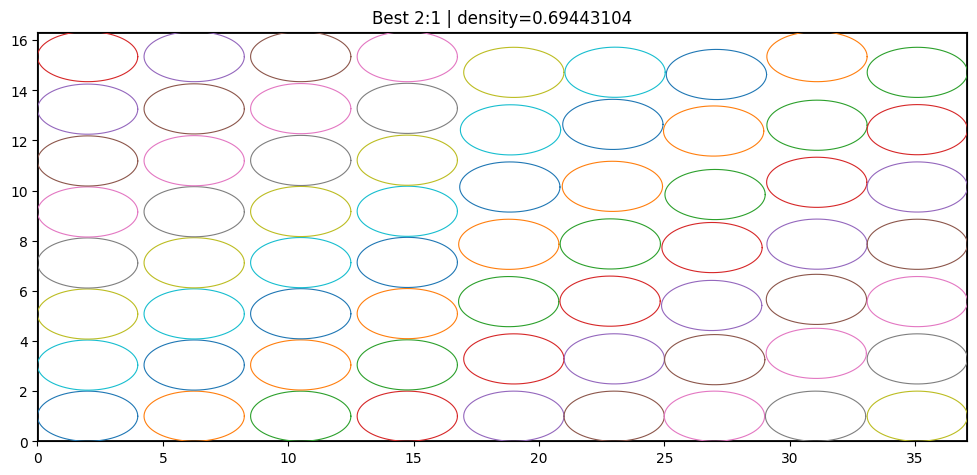

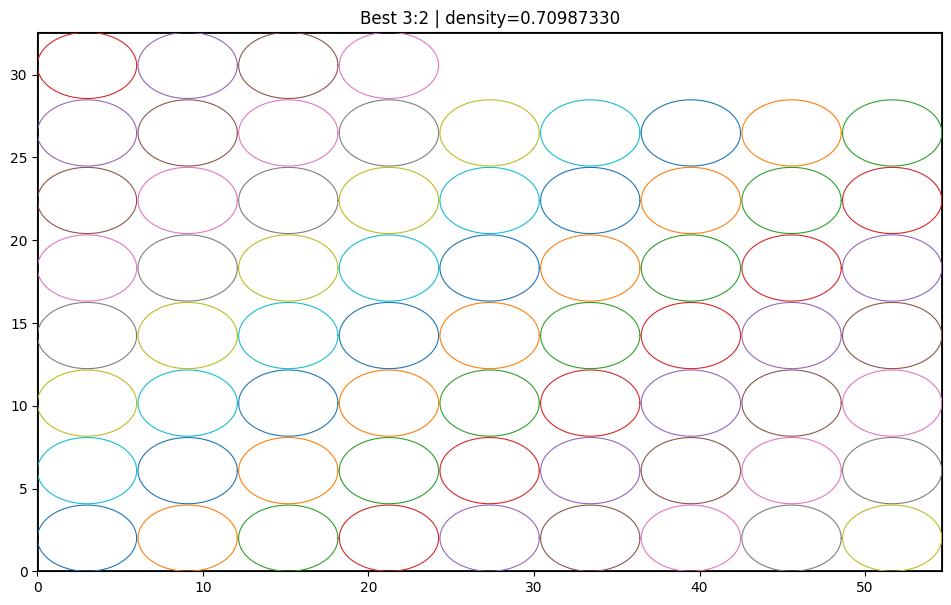

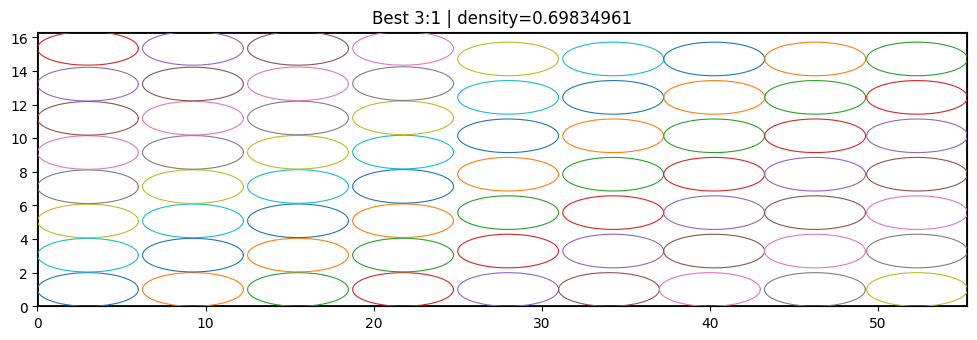

ROUND-TRIP VALIDATION PASSED
Saved: /kaggle/working/submission.csv


,row_id,submission_text
0,0,ratio: 2:1 37.0934720000*16.3428600540\n000: 2...


In [8]:
for name,s in best_states.items(): plot_packing(s,Geometry(*SHAPES[name]),f'Best {name} | density={density(s,Geometry(*SHAPES[name])):.8f}')
for name,s in best_states.items(): strict_validate(s,Geometry(*SHAPES[name]))
df=build_submission_csv(best_states,'/kaggle/working/submission.csv')
parsed=parse_submission_text(df.loc[0,'submission_text'])
for name,s in parsed.items(): strict_validate(s,Geometry(*SHAPES[name]))
print('ROUND-TRIP VALIDATION PASSED')
print('Saved:', '/kaggle/working/submission.csv')
display(df)

## 8. Strategy roadmap

After this baseline runs, compare initializer families, increase multi-start/SA budgets, benchmark exact collision speed, improve the broad phase, strengthen LNS neighborhoods, and only then consider evolutionary/ML-guided search. Record area, density, feasibility, runtime, candidate pairs, and orientation patterns for every experiment.